In [ ]:
!pip install -q scikit-learn tensorflow pandas numpy matplotlib tqdm
!pip install permetrics


import time, os, joblib, json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn import svm
from sklearn.svm import SVC, LinearSVC
from sklearn.calibration import CalibratedClassifierCV #
from sklearn.feature_selection import SelectKBest, mutual_info_classif, VarianceThreshold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, log_loss, roc_auc_score,
    ConfusionMatrixDisplay, confusion_matrix,
    roc_curve, auc, classification_report,
    rand_score, jaccard_score, fowlkes_mallows_score,silhouette_score, davies_bouldin_score, calinski_harabasz_score
)
from sklearn.cluster import KMeans
from permetrics import ClusteringMetric

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model

from tqdm import trange

from google.colab import drive
drive.mount('/content/drive')


In [ ]:
train_path = "/content/UNSW_NB15_training-set.csv"
test_path = "/content/UNSW_NB15_testing-set.csv"

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

display(df_train.head())
display(df_test.head())

print("Train shape:", df_train.shape)
print("Test shape:", df_test.shape)

print("\nColumns:")
print(df_train.columns)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0


Train shape: (175341, 45)
Test shape: (82332, 45)

Columns:
Index(['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes',
       'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss',
       'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin',
       'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth',
       'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm',
       'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm',
       'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm',
       'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label'],
      dtype='object')


In [ ]:
# Copy original data
train = df_train.copy()
test = df_test.copy()

train.drop(columns=['id'], inplace=True)
test.drop(columns=['id'], inplace=True)

print("Original train/test copied and 'id' removed.")

# Combine train + test for consistent preprocessing
combined = pd.concat([train, test], axis=0, ignore_index=True)
print("\nCombined dataset shape:", combined.shape)

# Reduce cardinality of 'service'
top_services = combined['service'].value_counts().nlargest(10).index
combined['service'] = combined['service'].apply(
    lambda x: x if x in top_services else 'other'
)

print("\nReduced cardinality of 'service'. Top services:", list(top_services))

# Light outlier handling (winsorization)
numeric_cols = combined.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    lower = combined[col].quantile(0.01)
    upper = combined[col].quantile(0.99)
    combined[col] = combined[col].clip(lower, upper)

print("\nOutlier clipping applied to numeric features (1st–99th percentile).")

# One-Hot Encoding for categorical features
categorical_cols = ['proto', 'service', 'state']

print("\nCategorical columns:", categorical_cols)
print("Applying One-Hot Encoding...")

combined = pd.get_dummies(combined, columns=categorical_cols, drop_first=True)

print("Encoding completed. New shape:", combined.shape)

# Separate features and target
X = combined.drop(columns=['label', 'attack_cat']).values
y = combined['label'].astype(int).values

print("\nUnique values of y:", np.unique(y))

# Standardization
scaler_path = "scaler_unsw.joblib"

if os.path.exists(scaler_path):
    print("\nScaler already exists, loading it...")
    scaler = joblib.load(scaler_path)
    X_scaled = scaler.transform(X)
else:
    print("\nScaler not found, creating and saving it...")
    scaler = StandardScaler().fit(X)
    X_scaled = scaler.transform(X)
    joblib.dump(scaler, scaler_path)
    print("Scaler saved.")

# Split back into train/test
X_train = X_scaled[:len(train)]
X_test = X_scaled[len(train):]

y_train = y[:len(train)]
y_test = y[len(train):]

print("\nTrain/test split completed.")
print("X_train:", X_train.shape, "X_test:", X_test.shape)

print("\nMean of scaled features (rounded):")
print(np.round(X_scaled.mean(axis=0), 2))

print("\nStd of scaled features (rounded):")
print(np.round(X_scaled.std(axis=0), 2))

print("Train - Normal:", (y_train==0).sum(), "  Attack:", (y_train==1).sum())
print("Test  - Normal:", (y_test==0).sum(),  "  Attack:", (y_test==1).sum())

Original train/test copied and 'id' removed.

Combined dataset shape: (257673, 44)

Reduced cardinality of 'service'. Top services: ['-', 'dns', 'http', 'smtp', 'ftp-data', 'ftp', 'pop3', 'ssh', 'dhcp', 'snmp']

Outlier clipping applied to numeric features (1st–99th percentile).

Categorical columns: ['proto', 'service', 'state']
Applying One-Hot Encoding...
Encoding completed. New shape: (257673, 193)

Unique values of y: [0 1]

Scaler not found, creating and saving it...
Scaler saved.

Train/test split completed.
X_train: (175341, 191) X_test: (82332, 191)

Mean of scaled features (rounded):
[ 0.  0.  0. -0.  0.  0.  0.  0.  0. -0.  0.  0.  0.  0. -0.  0.  0. -0.
 -0.  0.  0. -0.  0.  0.  0.  0. -0.  0. -0.  0.  0.  0. -0.  0.  0.  0.
 -0. -0. -0.  0.  0.  0.  0.  0. -0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0. -0.  0.
  0.  0.  0.  0.  0.  0.  0.  0. -0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
 -0.  0.  0.  0.  0.  0.  0.  0.  

In [ ]:
#Logistic Regression Model
logreg_path = "logreg_model.joblib"

if os.path.exists(logreg_path):
    print("Loading saved Logistic Regression model...")
    clf_log = joblib.load(logreg_path)

else:
    print("Training Logistic Regression with solver='liblinear'...")

    clf_log = LogisticRegression(
        solver="liblinear",
        C=1.0,
        max_iter=10000,
        class_weight='balanced'
    )

    clf_log.fit(X_train, y_train)
    joblib.dump(clf_log, logreg_path)
    print("Logistic Regression model saved.")

# === PREDICTIONS ===
y_pred_log = clf_log.predict(X_test)
y_proba_log = clf_log.predict_proba(X_test)


print("\n=== Logistic Regression Test Performance ===")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1-score:", f1_score(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_log[:, 1]))
print("Log-Loss:", log_loss(y_test, y_proba_log))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))



Training Logistic Regression with solver='liblinear'...
Logistic Regression model saved.

=== Logistic Regression Test Performance ===
Accuracy: 0.8401715007530486
Precision: 0.8086494368656344
Recall: 0.9297185211329745
F1-score: 0.8649680352176992
ROC-AUC: 0.9565432425278009
Log-Loss: 0.26132750674589394

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.73      0.80     37000
           1       0.81      0.93      0.86     45332

    accuracy                           0.84     82332
   macro avg       0.85      0.83      0.83     82332
weighted avg       0.85      0.84      0.84     82332



In [ ]:
# K-NN Model
knn_path = "knn_model.joblib"

if os.path.exists(knn_path):
    print("Loading saved KNN model...")
    knn, pca = joblib.load(knn_path)

else:
    print("Training full KNN model...")

    # PCA to reduce dimensionality ###
    pca = PCA(n_components=10)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)

    knn = KNeighborsClassifier(
        n_neighbors=3,
        algorithm='kd_tree', ###
        leaf_size=30
    )

    knn.fit(X_train_pca, y_train)

    joblib.dump((knn, pca), knn_path)
    print("KNN model saved.")


# PREDICTIONS
X_test_pca = pca.transform(X_test)
y_pred_knn = knn.predict(X_test_pca)
y_proba_knn = knn.predict_proba(X_test_pca)


print("\n=== KNN Test Performance ===")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall:", recall_score(y_test, y_pred_knn))
print("F1-score:", f1_score(y_test, y_pred_knn))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_knn[:, 1]))
print("Log-Loss:", log_loss(y_test, y_proba_knn))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))


Training full KNN model...
KNN model saved.

=== KNN Test Performance ===
Accuracy: 0.8527911383180294
Precision: 0.810392523364486
Recall: 0.9564104826612547
F1-score: 0.8773676542010684
ROC-AUC: 0.9102187381504862
Log-Loss: 2.499722008940633

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.73      0.82     37000
           1       0.81      0.96      0.88     45332

    accuracy                           0.85     82332
   macro avg       0.87      0.84      0.85     82332
weighted avg       0.86      0.85      0.85     82332



Although K-NN is known for its high computational cost on large datasets, applying PCA-based dimensionality reduction (from 191 to 10 components) made the model feasible while still training on the full dataset. This approach preserves the qualitative behavior of K-NN and enables large-scale evaluation without subsampling. The performance gap observed with respect to the first dataset is largely attributable to the aggressive dimensionality reduction rather than to the model itself: compressing 191 features into 10 principal components inevitably discards discriminative information, which is reflected in the higher Log-Loss and lower ROC-AUC. This trade-off is considered acceptable given the comparative nature of the analysis, where methodological consistency across models takes priority over per-model optimization.

In [ ]:
# Linear SVM (LinearSVC)
svm_path = "linear_svm_model.joblib"

if os.path.exists(svm_path):
    print("Loading saved Linear SVM model...")
    clf_svm = joblib.load(svm_path)

else:
    print("Training Linear SVM model...")

    # LinearSVC does NOT output probabilities
    base_svm = LinearSVC(class_weight='balanced')

    # Calibrated classifier to get predict_proba()
    clf_svm = CalibratedClassifierCV(base_svm, cv=3)

    clf_svm.fit(X_train, y_train)

    joblib.dump(clf_svm, svm_path)
    print("Linear SVM model saved.")

# PREDICTIONS
y_pred_svm = clf_svm.predict(X_test)
y_proba_svm = clf_svm.predict_proba(X_test)

print("\n=== Linear SVM Test Performance ===")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall:", recall_score(y_test, y_pred_svm))
print("F1-score:", f1_score(y_test, y_pred_svm))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_svm[:, 1]))
print("Log-Loss:", log_loss(y_test, y_proba_svm))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))


Training Linear SVM model...
Linear SVM model saved.

=== Linear SVM Test Performance ===
Accuracy: 0.8087620852159549
Precision: 0.7465295715499858
Recall: 0.9881981822994794
F1-score: 0.8505301929959465
ROC-AUC: 0.9426892762346746
Log-Loss: 0.3992383413136388

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.59      0.73     37000
           1       0.75      0.99      0.85     45332

    accuracy                           0.81     82332
   macro avg       0.86      0.79      0.79     82332
weighted avg       0.85      0.81      0.80     82332



LinearSVC was selected instead of an SVM with an RBF kernel due to the very large size of the UNSW-NB15 dataset. Non-linear SVMs have quadratic computational complexity with respect to the number of samples, making them impractical to train on large datasets even after dimensionality reduction. In contrast, LinearSVC scales linearly with the number of samples, trains in a few seconds, and allows the use of the full training set without subsampling. This makes it a more efficient and scalable choice while still providing a strong linear baseline for comparison with more complex models. However, the results suggest that the UNSW-NB15 dataset is not linearly separable: the model consistently misclassified a large fraction of normal traffic regardless of class weighting, indicating that the performance bottleneck stems from the linear decision boundary itself rather than from class imbalance.

In [ ]:
# Artificial Neural Network Model
ann_path = "ann_model_unsw.keras"
ann_params_path = "ann_params_unsw.json"
ann_history_path = "ann_history_unsw.json"

if os.path.exists(ann_path):
    print("Loading saved ANN model...")
    ann = load_model(ann_path)

    print("\nANN architecture:")
    ann.summary()

    print("\nLearning rate:", ann.optimizer.learning_rate.numpy())

else:
    print("ANN model not found, training it...")

    tf.random.set_seed(42)

    n_features = X_train.shape[1]

    # Model architecture
    model = Sequential([
        Dense(128, activation='relu', input_shape=(n_features,)),
        Dropout(0.3),

        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),

        Dense(32, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),

        Dense(1, activation='sigmoid')
    ])


    optimizer = Adam(learning_rate=0.0005)

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    # Callbacks
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=6,
        restore_best_weights=True
    )

    lr_scheduler = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )


    history = model.fit(
        X_train, y_train,
        epochs=60,
        batch_size=128,
        validation_split=0.3,
        callbacks=[early_stop, lr_scheduler],
        verbose=1
    )

    model.save(ann_path)
    ann = model

    with open(ann_params_path, "w") as f:
        json.dump({
            "learning_rate": 0.0005,
            "batch_size": 128,
            "epochs": 60,
            "architecture": "64-32-16-1 with BN + Dropout",
            "notes": "Optimized for UNSW-NB15"
        }, f)

    with open(ann_history_path, "w") as f:
      json.dump(history.history, f)

    print("\nANN model saved.")
    ann.summary()
    print("\nLearning rate:", ann.optimizer.learning_rate.numpy())

# PREDICTIONS

proba_ann = ann.predict(X_test).ravel()
pred_ann = (proba_ann > 0.5).astype(int)

test_loss, test_acc = ann.evaluate(X_test, y_test, verbose=0)
print(f"\nANN Test Loss: {test_loss:.4f}")
print(f"ANN Test Accuracy: {test_acc:.4f}")

print("\n=== ANN Test Performance ===")
print("Accuracy:", accuracy_score(y_test, pred_ann))
print("Precision:", precision_score(y_test, pred_ann))
print("Recall:", recall_score(y_test, pred_ann))
print("F1-score:", f1_score(y_test, pred_ann))
print("ROC-AUC:", roc_auc_score(y_test, proba_ann))
print("Log-Loss:", log_loss(y_test, proba_ann))

print("\nClassification Report:")
print(classification_report(y_test, pred_ann))



ANN model not found, training it...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/60
959/959 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8408 - loss: 0.3356 - val_accuracy: 0.9942 - val_loss: 0.0528 - learning_rate: 5.0000e-04
Epoch 2/60
959/959 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9070 - loss: 0.1932 - val_accuracy: 0.9956 - val_loss: 0.0429 - learning_rate: 5.0000e-04
Epoch 3/60
959/959 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9079 - loss: 0.1834 - val_accuracy: 0.9963 - val_loss: 0.0416 - learning_rate: 5.0000e-04
Epoch 4/60
959/959 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9097 - loss: 0.1771 - val_accuracy: 0.9921 - val_loss: 0.0391 - learning_rate: 5.0000e-04
Epoch 5/60
959/959 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9117 - loss: 0.1735 - val_accuracy: 0.9938 - val_loss: 0.0413 - learning_rate: 5.0000e-04
Epoch 6/60
959/959 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9137 - loss: 0.1705 - val_accuracy: 0.9935 - val_loss: 0.0406 - learning_rate: 5.0000e-04
Epoch 7/60
959/959 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        24,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,605 (412.52 KB)

 Trainable params: 35,137 (137.25 KB)

 Non-trainable params: 192 (768.00 B)

 Optimizer params: 70,276 (274.52 KB)


Learning rate: 6.25e-05
2573/2573 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step

ANN Test Loss: 0.2455
ANN Test Accuracy: 0.8494

=== ANN Test Performance ===
Accuracy: 0.8494145654180635
Precision: 0.7953616013775291
Recall: 0.9781831818582899
F1-score: 0.8773495310830597
ROC-AUC: 0.9760483791057447
Log-Loss: 0.2454503383854609

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.69      0.81     37000
           1       0.80      0.98      0.88     45332

    accuracy                           0.85     82332
   macro avg       0.88      0.83      0.84     82332
weighted avg       0.87      0.85      0.84     82332



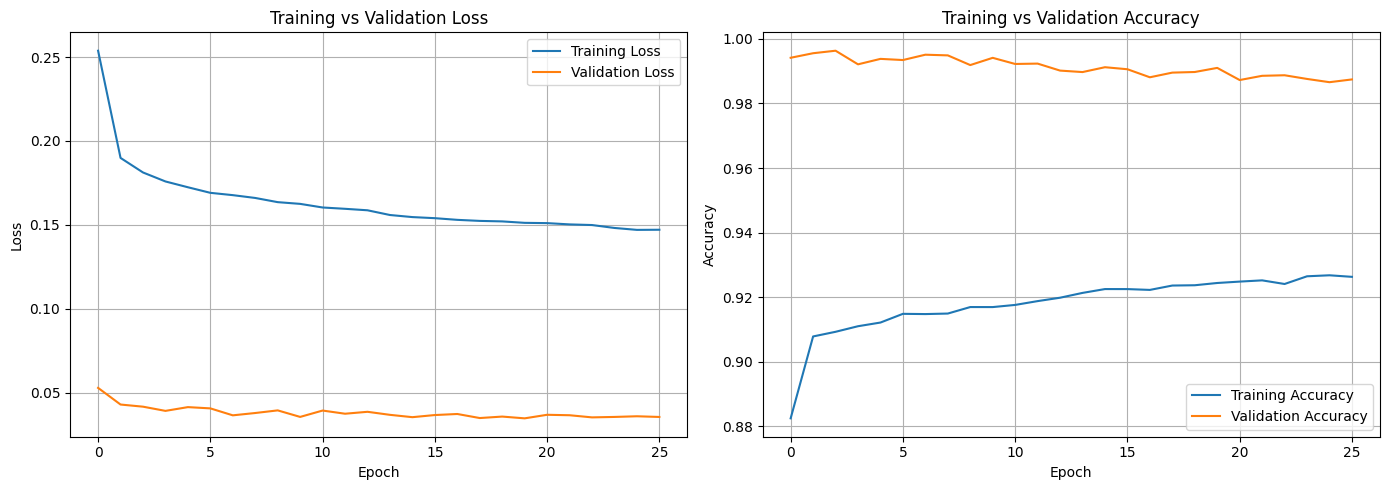

In [ ]:
plt.figure(figsize=(14, 5))

# Subplot 1: Loss

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Subplot 2: Accuracy

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


The first dataset exhibits the canonical convergence pattern where training and validation loss decrease jointly. In the second dataset, the inverted pattern is attributable to the heavier Dropout regularization required by the larger and more complex dataset, which penalizes training loss while leaving validation unaffected. The strong test metrics confirm that the model generalizes effectively despite the atypical appearance of the learning curves.

In [ ]:
# Decision Tree Model
dt_path = "dt_model.joblib"


if os.path.exists(dt_path):
    print("Loading saved Decision Tree model...")
    dt = joblib.load(dt_path)
    print("DT parameters:", dt.get_params())

else:
    print("Decision Tree model not found, training it...")

    dt = DecisionTreeClassifier(
        criterion="gini",
        max_depth=None,
        min_samples_split=50,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=42
    )

    dt.fit(X_train, y_train)

    joblib.dump(dt, dt_path)
    print("Decision Tree model saved.")
    print("DT parameters:", dt.get_params())

# PREDICTIONS

y_pred_dt = dt.predict(X_test)
y_proba_dt = dt.predict_proba(X_test)[:, 1]

print("\n=== Decision Tree Test Performance ===")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1-score:", f1_score(y_test, y_pred_dt))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_dt))
print("Log-Loss:", log_loss(y_test, y_proba_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))


Decision Tree model not found, training it...
Decision Tree model saved.
DT parameters: {'ccp_alpha': 0.0, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 10, 'min_samples_split': 50, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}

=== Decision Tree Test Performance ===
Accuracy: 0.8888038672691055
Precision: 0.8563323680633532
Recall: 0.9589252625077208
F1-score: 0.9047296945730787
ROC-AUC: 0.951548467343634
Log-Loss: 1.211156642626441

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.80      0.87     37000
           1       0.86      0.96      0.90     45332

    accuracy                           0.89     82332
   macro avg       0.90      0.88      0.89     82332
weighted avg       0.89      0.89      0.89     82332



In [ ]:
# Random Forest Model
rf_path = "rf_model.joblib"

if os.path.exists(rf_path):
    print("Loading saved Random Forest model...")
    rf = joblib.load(rf_path)
    print("RF parameters:", rf.get_params())

else:
    print("Random Forest model not found, training it...")

    rf = RandomForestClassifier(
        n_estimators=300,
        criterion="gini",
        max_depth=25,
        min_samples_split=20,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train, y_train)

    joblib.dump(rf, rf_path)
    print("Random Forest model saved.")
    print("RF parameters:", rf.get_params())


# PREDICTIONS

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("\n=== Random Forest Test Performance ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))
print("Log-Loss:", log_loss(y_test, y_proba_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))


Random Forest model not found, training it...
Random Forest model saved.
RF parameters: {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 25, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 5, 'min_samples_split': 20, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 300, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}

=== Random Forest Test Performance ===
Accuracy: 0.9029053102074528
Precision: 0.8680216054250118
Recall: 0.9713447454336892
F1-score: 0.9167811784301478
ROC-AUC: 0.9842169572952464
Log-Loss: 0.1931688482004673

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.82      0.88     37000
           1       0.87      0.97      0.92     45332

    accuracy                           0.90     82332
   macro avg       0.91      0.90      0.

In [ ]:
metrics_dict = {
    "Logistic Regression": {
        "Accuracy": accuracy_score(y_test, y_pred_log),
        "Precision": precision_score(y_test, y_pred_log),
        "Recall": recall_score(y_test, y_pred_log),
        "F1": f1_score(y_test, y_pred_log),
        "ROC-AUC": roc_auc_score(y_test, y_proba_log[:,1]),
        "Log-loss": log_loss(y_test, y_proba_log)
    },
    "k-NN": {
        "Accuracy": accuracy_score(y_test, y_pred_knn),
        "Precision": precision_score(y_test, y_pred_knn),
        "Recall": recall_score(y_test, y_pred_knn),
        "F1": f1_score(y_test, y_pred_knn),
        "ROC-AUC": roc_auc_score(y_test, y_proba_knn[:,1]),
        "Log-loss": log_loss(y_test, y_proba_knn)
    },
    "SVM": {
        "Accuracy": accuracy_score(y_test, y_pred_svm),
        "Precision": precision_score(y_test, y_pred_svm),
        "Recall": recall_score(y_test, y_pred_svm),
        "F1": f1_score(y_test, y_pred_svm),
        "ROC-AUC": roc_auc_score(y_test, y_proba_svm[:,1]),
        "Log-loss": log_loss(y_test, y_proba_svm)
    },
    "ANN": {
        "Accuracy": accuracy_score(y_test, pred_ann),
        "Precision": precision_score(y_test, pred_ann),
        "Recall": recall_score(y_test, pred_ann),
        "F1": f1_score(y_test, pred_ann),
        "ROC-AUC": roc_auc_score(y_test, proba_ann),
        "Log-loss": log_loss(y_test, proba_ann)
    },
    "Decision Tree": {
        "Accuracy": accuracy_score(y_test, y_pred_dt),
        "Precision": precision_score(y_test, y_pred_dt),
        "Recall": recall_score(y_test, y_pred_dt),
        "F1": f1_score(y_test, y_pred_dt),
        "ROC-AUC": roc_auc_score(y_test, y_proba_dt),
        "Log-loss": log_loss(y_test, y_proba_dt)
    },
    "Random Forest": {
        "Accuracy": accuracy_score(y_test, y_pred_rf),
        "Precision": precision_score(y_test, y_pred_rf),
        "Recall": recall_score(y_test, y_pred_rf),
        "F1": f1_score(y_test, y_pred_rf),
        "ROC-AUC": roc_auc_score(y_test, y_proba_rf),
        "Log-loss": log_loss(y_test, y_proba_rf)
    }
}


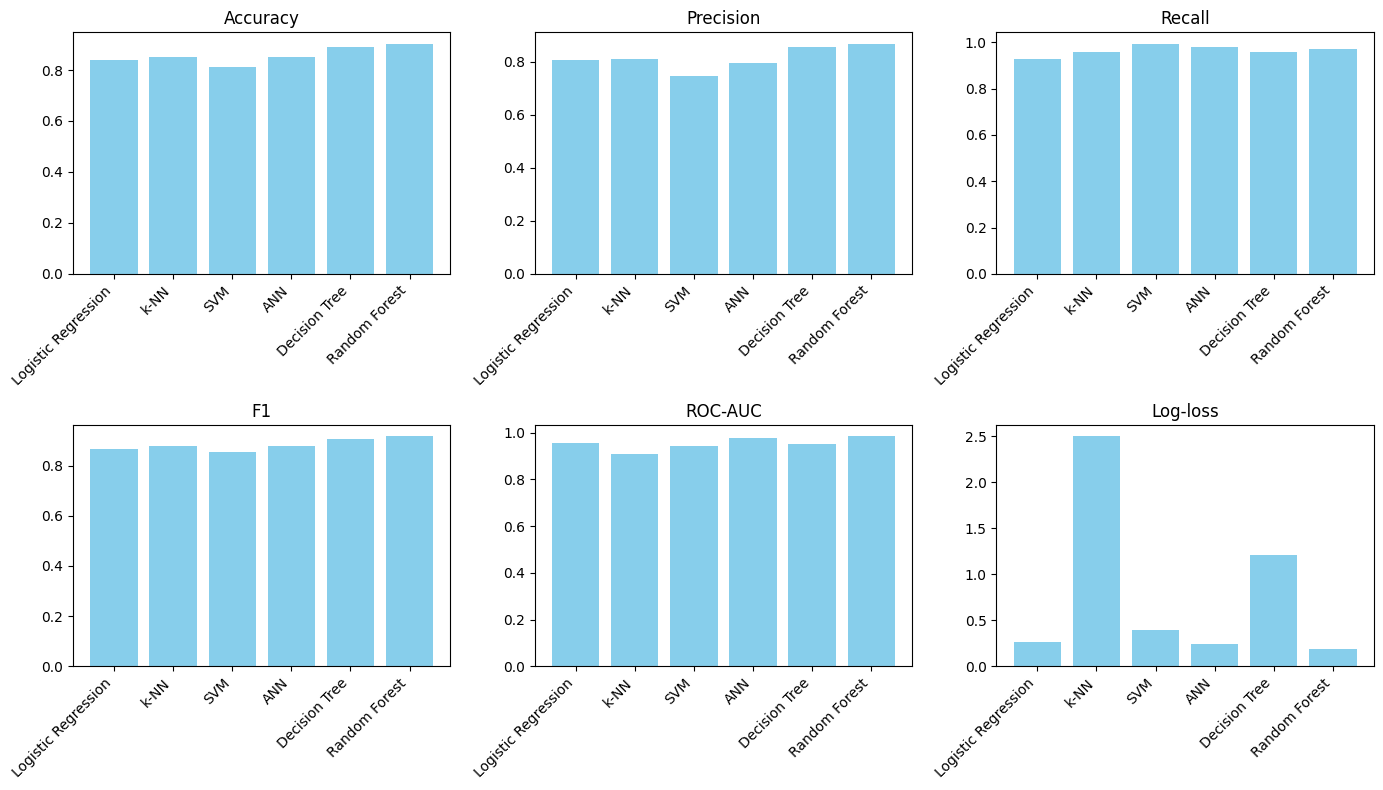

In [ ]:
models = list(metrics_dict.keys())
metric_names = list(metrics_dict["Logistic Regression"].keys())

plt.figure(figsize=(14, 8))

for i, metric in enumerate(metric_names):
    plt.subplot(2, 3, i+1)
    values = [metrics_dict[m][metric] for m in models]
    plt.bar(models, values, color='skyblue')
    plt.title(metric)
    plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig("SecondDatasetMetrics.png", dpi=300, bbox_inches='tight')
plt.show()


 i modelli tree-based (RF e DT) dominano su UNSW-NB15, i modelli lineari hanno limiti strutturali, KNN e ANN stanno nel mezzo. Questa è esattamente il tipo di analisi comparativa che un progetto IDS dovrebbe mostrare.

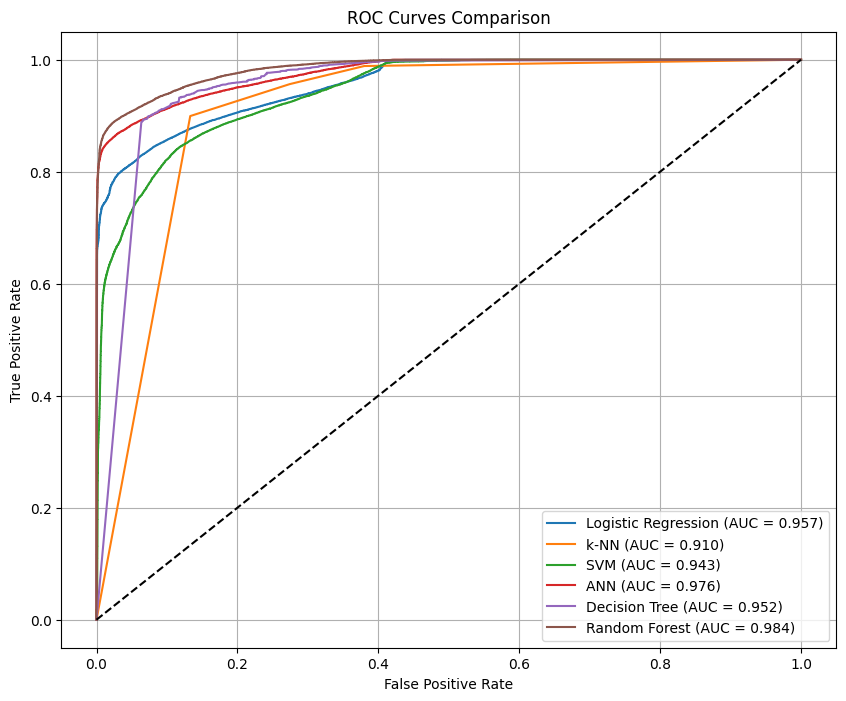

In [ ]:
plt.figure(figsize=(10, 8))

def plot_roc(y_test, y_proba, label):
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{label} (AUC = {roc_auc:.3f})")

plot_roc(y_test, y_proba_log[:,1], "Logistic Regression")
plot_roc(y_test, y_proba_knn[:,1], "k-NN")
plot_roc(y_test, y_proba_svm[:,1], "SVM")
plot_roc(y_test, proba_ann, "ANN")
plot_roc(y_test, y_proba_dt, "Decision Tree")
plot_roc(y_test, y_proba_rf, "Random Forest")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves Comparison")
plt.legend()
plt.grid(True)
plt.savefig("SecondDatasetROCCurves.png", dpi=300, bbox_inches='tight')
plt.show()


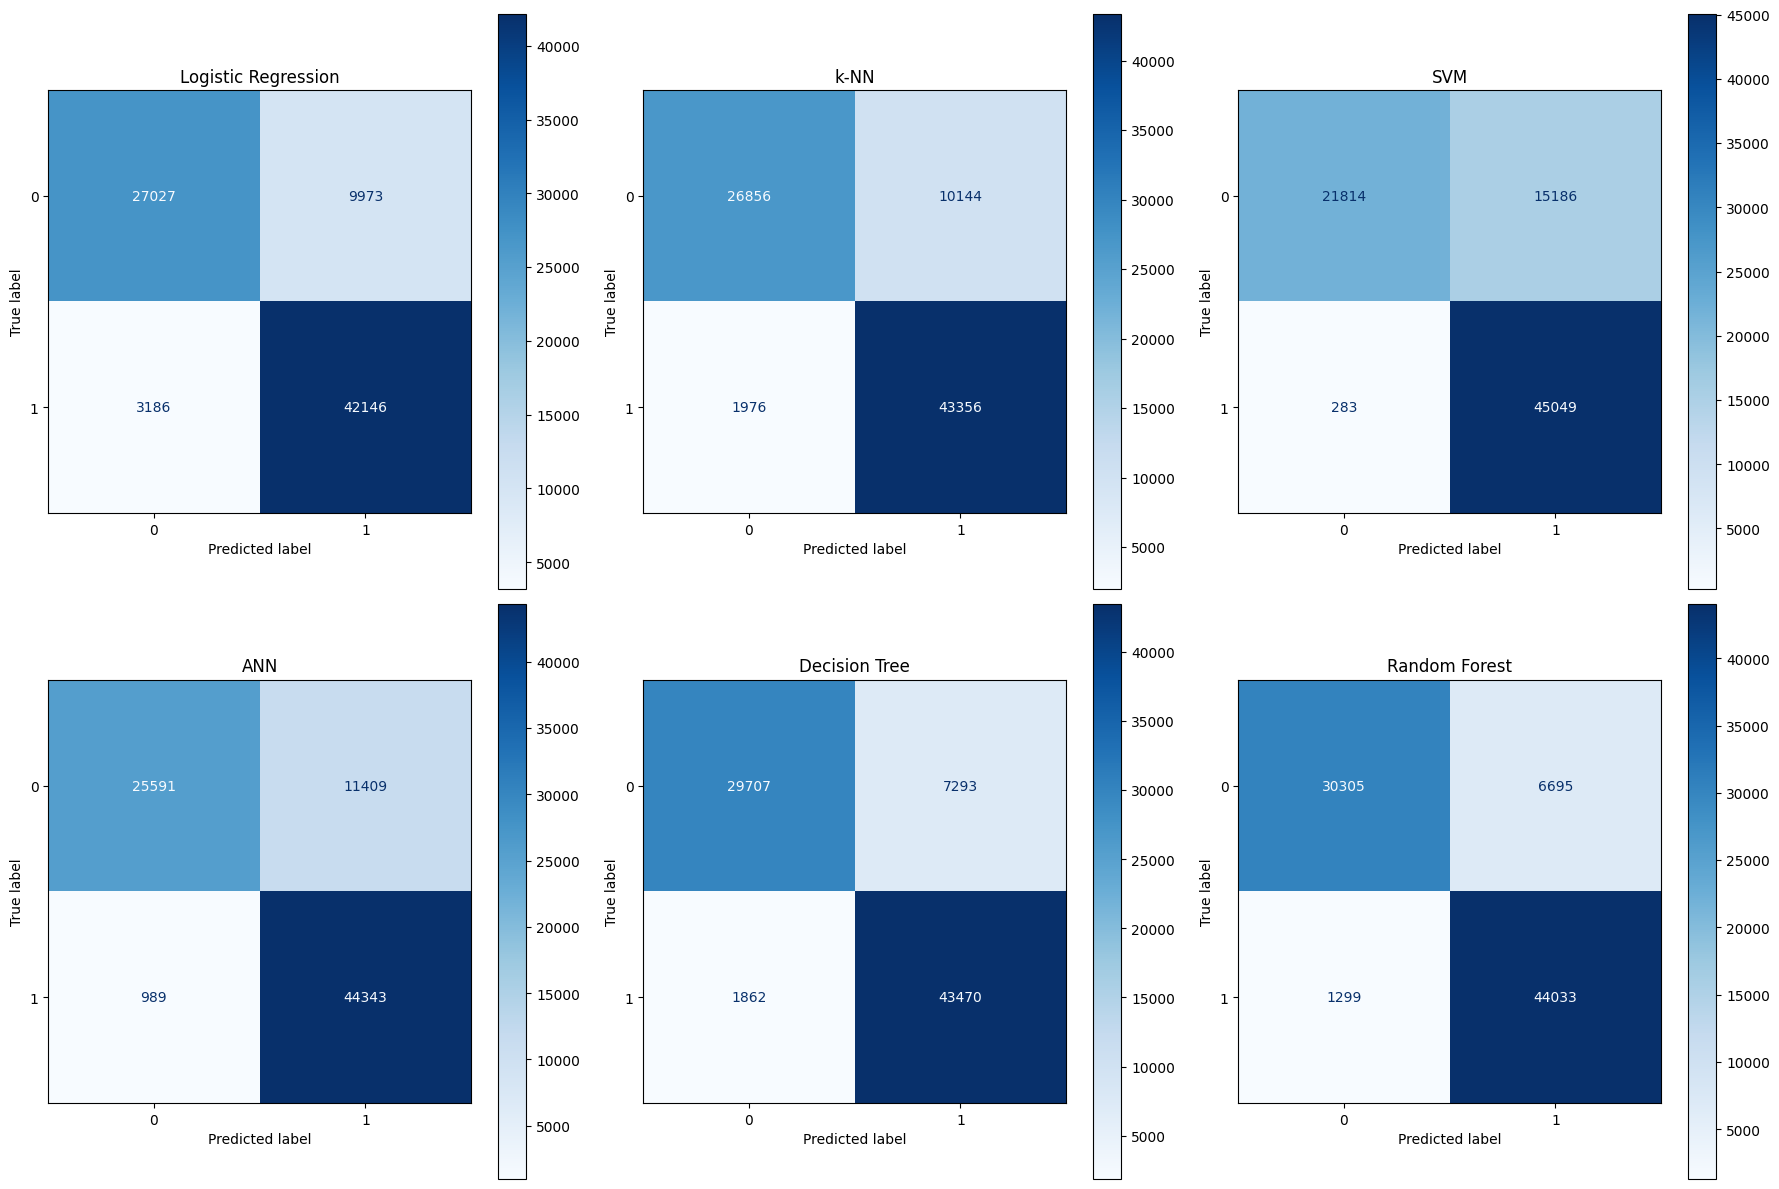

In [ ]:
models_preds = {
    "Logistic Regression": y_pred_log,
    "k-NN": y_pred_knn,
    "SVM": y_pred_svm,
    "ANN": pred_ann,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf
}

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for ax, (name, preds) in zip(axes.flatten(), models_preds.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, preds, cmap='Blues', values_format='d', ax=ax
    )
    ax.set_title(name)

plt.tight_layout()
plt.savefig("SecondDatasetConfusionMatrix.png", dpi=300, bbox_inches='tight')
plt.show()


The comparative evaluation of all models on the UNSW‑NB15 dataset shows clear and consistent results. The Random Forest achieves the best overall performance, with the highest accuracy, F1‑score, and ROC‑AUC, and a confusion matrix that demonstrates an excellent balance between detecting attacks and minimizing false alarms. The Artificial Neural Network also performs very well, ranking second with strong generalization ability and a high ROC‑AUC.

The SVM achieves an extremely low number of false negatives but produces more false positives, reflecting its tendency to prioritize recall on imbalanced datasets. The Decision Tree provides acceptable results but remains less stable and less accurate than the Random Forest. Finally, Logistic Regression and k‑NN show the weakest performance, struggling with the non‑linear and high‑dimensional nature of the dataset.

Overall, the results indicate that Random Forest and ANN are the most suitable models for intrusion detection on UNSW‑NB15, offering the best trade‑off between accuracy, robustness, and detection capability.

In [ ]:
# CLUSTERING (K-MEANS)
kmeans_path = "kmeans_model.joblib"

if os.path.exists(kmeans_path):
    print("Carico K-Means salvato...")
    kmeans = joblib.load(kmeans_path)
    cluster_labels = kmeans.predict(X_scaled)

else:
    print("Modello K-Means NON trovato, lo alleno...")

    kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)

    joblib.dump(kmeans, kmeans_path)
    print("K-Means salvato.")

print("Clustering completed.")

# SAMPLE FOR METRICS
sample_size = 10000

if X_scaled.shape[0] > sample_size:
    idx = np.random.choice(X_scaled.shape[0], sample_size, replace=False)
    X_sample = X_scaled[idx]
    labels_sample = cluster_labels[idx]
else:
    X_sample = X_scaled
    labels_sample = cluster_labels

print("Using sample of:", X_sample.shape[0], "points for internal metrics.")

# EXTERNAL METRICS
RI  = rand_score(y, cluster_labels)
FMI = fowlkes_mallows_score(y, cluster_labels)
JI  = jaccard_score(y, cluster_labels)

# INTERNAL METRICS
SI  = silhouette_score(X_sample, labels_sample)
DBI = davies_bouldin_score(X_sample, labels_sample)
CHI = calinski_harabasz_score(X_sample, labels_sample)

cm = ClusteringMetric(X=X_sample, y_pred=labels_sample)
DI = cm.dunn_index()

print("\n=== External Validity Metrics ===")
print(f"Rand Index (RI): {RI:.6f}")
print(f"Fowlkes-Mallows Index (FMI): {FMI:.6f}")
print(f"Jaccard Index (JI): {JI:.6f}")

print("\n=== Internal Validity Metrics ===")
print(f"Silhouette Index (SI): {SI:.6f}")
print(f"Davies-Bouldin Index (DBI): {DBI:.6f}")
print(f"Calinski-Harabasz Index (CHI): {CHI:.6f}")

print("\n=== Dunn Index (DI) ===")
print(f"Dunn Index (DI): {DI:.6f}")


Carico K-Means salvato...
Clustering completed.
Using sample of: 10000 points for internal metrics.

=== External Validity Metrics ===
Rand Index (RI): 0.558651
Fowlkes-Mallows Index (FMI): 0.576251
Jaccard Index (JI): 0.561438

=== Internal Validity Metrics (sampled) ===
Silhouette Index (SI): 0.177212
Davies-Bouldin Index (DBI): 2.273464
Calinski-Harabasz Index (CHI): 796.832149

=== Dunn Index (DI) ===
Dunn Index (DI): 0.076383


K-Means clustering achieved substantially better alignment with the ground-truth labels on the first dataset, as reflected by higher external validity indices and a more favorable internal structure. On UNSW-NB15, the overlapping nature of traffic classes results in less separable clusters, consistent with the classification results observed across all supervised models. It should be noted that internal validity metrics for the second dataset were computed on a 10,000-point subsample due to computational constraints, which limits direct comparison with the first dataset where full-data evaluation was performed.

In [ ]:
clustering_metrics = {
    "Rand Index (RI)": RI,
    "Fowlkes-Mallows (FMI)": FMI,
    "Jaccard Index (JI)": JI,
    "Silhouette Index (SI)": SI,
    "Davies-Bouldin (DBI)": DBI,
    "Calinski-Harabasz (CHI)": CHI,
    "Dunn Index (DI)": DI
}
print("\n=== Clustering Metrics Summary ===")
display(pd.DataFrame.from_dict(clustering_metrics, orient='index', columns=['Value']))



=== Clustering Metrics Summary ===


,Value
Rand Index (RI),0.604250
Fowlkes-Mallows (FMI),0.620158
Jaccard Index (JI),0.605663
Silhouette Index (SI),0.575878
Davies-Bouldin (DBI),0.677885
Calinski-Harabasz (CHI),11732.906484
Dunn Index (DI),0.050079


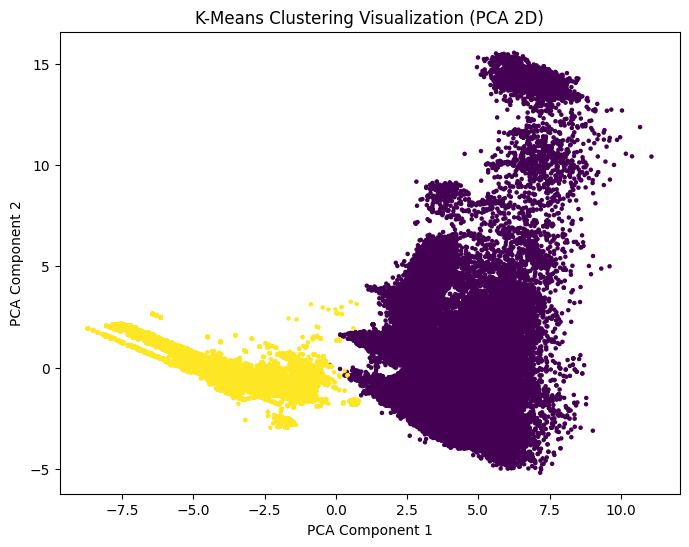

In [ ]:
# PCA Visualization of Clusters
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=cluster_labels, cmap='viridis', s=5)
plt.title("K-Means Clustering Visualization (PCA 2D)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.savefig("SecondDatasetPCAClustering.png", dpi=300, bbox_inches='tight')
plt.show()


The PCA projection highlights how K‑Means separates the data into two compact and visually distinguishable clusters, indicating that the underlying structure of the dataset contains meaningful partitioning that the algorithm is able to capture even in a reduced two‑dimensional space.

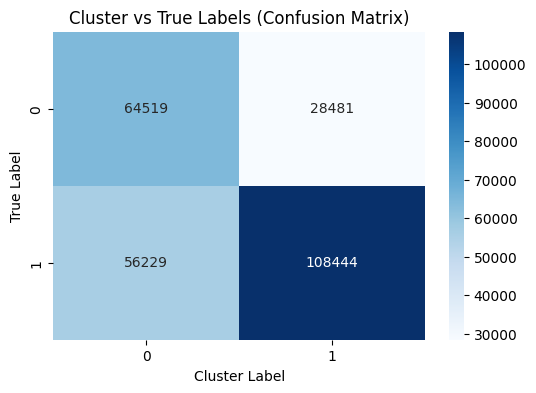

In [ ]:
# Heatmap: Cluster vs True Labels

# Compute confusion matrix between cluster labels and true labels
cm = confusion_matrix(y, cluster_labels)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Cluster vs True Labels (Confusion Matrix)")
plt.xlabel("Cluster Label")
plt.ylabel("True Label")
plt.savefig("SecondDatasetConfusionMatrixClustering.png", dpi=300, bbox_inches='tight')
plt.show()


The confusion matrix reveals that the clusters only partially align with the true labels, showing substantial overlap between classes; this indicates that while K‑Means captures some underlying structure, the dataset is not naturally separable into the two true categories using unsupervised clustering alone.

The PCA visualizations and confusion matrices highlight a stark contrast between the two datasets. On the first dataset, K-Means achieves near-perfect identification of normal traffic and good separation of attacks, with clusters that are geometrically distinct in the reduced space. On UNSW-NB15, the substantially higher overlap between classes reflects the greater diversity of attack types and the more complex feature interactions, resulting in a clustering solution that only partially aligns with the ground-truth labels.

In [ ]:
# CONVERGENCE EXPERIMENT
def tr_logreg(X_train, y_train, X_test):
    clf = LogisticRegression(
        solver="liblinear",
        C=0.3,
        max_iter=2000
    )
    clf.fit(X_train, y_train)
    return clf.predict(X_test)

def tr_knn(X_train, y_train, X_test):
    pca = PCA(n_components=5)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)

    knn = KNeighborsClassifier(
        n_neighbors=1,
        algorithm='kd_tree'
    )
    knn.fit(X_train_pca, y_train)
    return knn.predict(X_test_pca)

def tr_svm(X_train, y_train, X_test):
    svm = LinearSVC(
        C=1.0,
        class_weight="balanced",
        max_iter=5000
    )
    svm.fit(X_train, y_train)
    return svm.predict(X_test)

def tr_dt(X_train, y_train, X_test):
    dt = DecisionTreeClassifier(
        criterion="gini",
        max_depth=10,
        min_samples_split=20,
        random_state=42
    )
    dt.fit(X_train, y_train)
    return dt.predict(X_test)

def tr_rf(X_train, y_train, X_test):
    rf = RandomForestClassifier(
        n_estimators=50,
        max_depth=10,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)
    return rf.predict(X_test)

def tr_ann(X_train, y_train, X_test):
    n_features = X_train.shape[1]

    model = tf.keras.Sequential([
        tf.keras.Input(shape=(n_features,)),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='loss',
        patience=1,
        restore_best_weights=True
    )

    model.fit(
        X_train, y_train,
        epochs=5,          # ridotto per velocità
        batch_size=64,
        verbose=0,
        callbacks=[early_stop]
    )

    proba = model.predict(X_test, verbose=0).ravel()
    return (proba > 0.5).astype(int)


In [ ]:
def train_and_eval(model_func, X_train, y_train, X_test, y_test):
    # model_func is directly the function tr_logreg, tr_svm, etc.
    pred = model_func(X_train, y_train, X_test)

    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred, average="weighted")
    return acc, f1

In [ ]:
training_sizes = np.linspace(0.1, 1.0, 10)   # 10 values
n_iterations = 100                           # 100 iterations

models = {
    "LogisticRegression": tr_logreg,
    "KNN": tr_knn,
    "SVM": tr_svm,
    "DecisionTree": tr_dt,
    "RandomForest": tr_rf,
    "ANN": tr_ann
}

results_accuracy = {m: {float(s): [] for s in training_sizes} for m in models}
results_f1 = {m: {float(s): [] for s in training_sizes} for m in models}

In [ ]:
def get_subsample(X_full, y_full, n_samples):
    if n_samples >= len(X_full):
        return X_full, y_full
    try:
        X_sub, _, y_sub, _ = train_test_split(
            X_full, y_full, train_size=n_samples, stratify=y_full
        )
    except:
        X_sub, _, y_sub, _ = train_test_split(
            X_full, y_full, train_size=n_samples, stratify=None
        )
    return X_sub, y_sub

In [ ]:
# 🔒 Wait until Drive is fully synchronized
while not os.path.exists("/content/drive/MyDrive"):
    print("⏳ Waiting for Google Drive synchronization...")
    time.sleep(1)

print("Drive successfully synchronized.")

# Drive check
if not os.path.exists("/content/drive"):
    print("⚠️ Drive is not mounted! Mount it first with drive.mount('/content/drive').")
else:
    print("Drive mounted correctly.")

# Folder on Drive
save_dir = "/content/drive/MyDrive/convergence_results2"
os.makedirs(save_dir, exist_ok=True)
print(f"Save directory: {save_dir}")

Drive successfully synchronized.
Drive mounted correctly.
Save directory: /content/drive/MyDrive/convergence_results2


In [ ]:
BASE_DIR = "/content/drive/MyDrive/convergence_results2"

def save_partial_results(model_name, train_size, acc_list, f1_list):
    folder = f"{BASE_DIR}/{model_name}"
    os.makedirs(folder, exist_ok=True)

    filename = f"{folder}/size_{train_size:.2f}.json"
    data = {"accuracy": acc_list, "f1": f1_list}

    with open(filename, "w") as f:
        json.dump(data, f, indent=4)

    print(f"> Partial save completed → {filename}")


def load_partial_results(model_name, train_size):
    filename = f"{BASE_DIR}/{model_name}/size_{train_size:.2f}.json"
    if not os.path.exists(filename):
        return None

    with open(filename, "r") as f:
        data = json.load(f)

    print(f"📂 File found and loaded → {filename}")
    return data["accuracy"], data["f1"]

In [ ]:
results_accuracy = {
    m: {str(float(size)): [] for size in training_sizes}
    for m in models
}

results_f1 = {
    m: {str(float(size)): [] for size in training_sizes}
    for m in models
}

# MAIN LOOP
for s in training_sizes:

    print(f"\n=== Training size {s:.2f} ===")
    print("→ Checking partial files for each model...")

    n_samples = max(1, int(len(X_train) * s))

    for model_name, model_func in models.items():

        print("\n" + "-"*60)
        print(f"MODEL: {model_name}")
        print(f"Training size: {s:.2f} ({n_samples} samples)")
        print("-"*60)

        loaded = load_partial_results(model_name, s)

        if loaded is not None:
            acc_list, f1_list = loaded
            start_iter = len(acc_list)
            print(f"Iterations already present in file: {start_iter}")
        else:
            acc_list, f1_list = [], []
            start_iter = 0
            print("→ No partial file found, starting from scratch.")

        remaining = n_iterations - start_iter
        print(f"> Iterations completed: {start_iter}, remaining: {remaining}")

        print(f"Training size {s:.2f} ({n_iterations} iterations)")

        #ITERATION LOOP
        for it in range(start_iter, n_iterations):

            X_sub, y_sub = get_subsample(X_train, y_train, n_samples)

            acc, f1 = train_and_eval(model_func, X_sub, y_sub, X_test, y_test)
            acc_list.append(acc)
            f1_list.append(f1)

            if (it + 1) % 10 == 0:
                print(f"⏳ Iteration {it + 1}/{n_iterations} completed")

            if (it + 1) % 50 == 0 or (it + 1) == n_iterations:
                print(f"Partial save → {model_name} | size {s:.2f} | iter {it+1}")
                save_partial_results(model_name, s, acc_list, f1_list)

        # Final save
        print(f"> Final file saved for {model_name} | size {s:.2f}")
        save_partial_results(model_name, s, acc_list, f1_list)

        final_iters = len(acc_list)
        print(f"📊 Total iterations saved for {model_name} | size {s:.2f}: {final_iters}")

        if final_iters != n_iterations:
            print("⚠️ WARNING: unexpected number of iterations!")



=== Training size 0.10 ===
→ Checking partial files for each model...

------------------------------------------------------------
MODEL: LogisticRegression
Training size: 0.10 (17534 samples)
------------------------------------------------------------
📂 File found and loaded → /content/drive/MyDrive/convergence_results2/LogisticRegression/size_0.10.json
Iterations already present in file: 100
⚠️ If you do NOT want to continue from here, delete the file before rerunning.
> Iterations completed: 100, remaining: 0
Training size 0.10 (100 iterations)
> Final file saved for LogisticRegression | size 0.10
> Partial save completed → /content/drive/MyDrive/convergence_results2/LogisticRegression/size_0.10.json
📊 Total iterations saved for LogisticRegression | size 0.10: 100

------------------------------------------------------------
MODEL: KNN
Training size: 0.10 (17534 samples)
------------------------------------------------------------
📂 File found and loaded → /content/drive/MyDrive/

In [ ]:
BASE_DIR = "/content/drive/MyDrive/convergence_results2"

results_accuracy = {m: {} for m in models}
results_f1 = {m: {} for m in models}

for m in models:
    model_dir = f"{BASE_DIR}/{m}"
    for s in training_sizes:
        filename = f"{model_dir}/size_{s:.2f}.json"
        if os.path.exists(filename):
            with open(filename, "r") as f:
                data = json.load(f)
            results_accuracy[m][f"{s:.2f}"] = data["accuracy"]
            results_f1[m][f"{s:.2f}"] = data["f1"]
        else:
            results_accuracy[m][f"{s:.2f}"] = []
            results_f1[m][f"{s:.2f}"] = []


In [ ]:
results_accuracy["LogisticRegression"].keys()

dict_keys(['0.10', '0.20', '0.30', '0.40', '0.50', '0.60', '0.70', '0.80', '0.90', '1.00'])

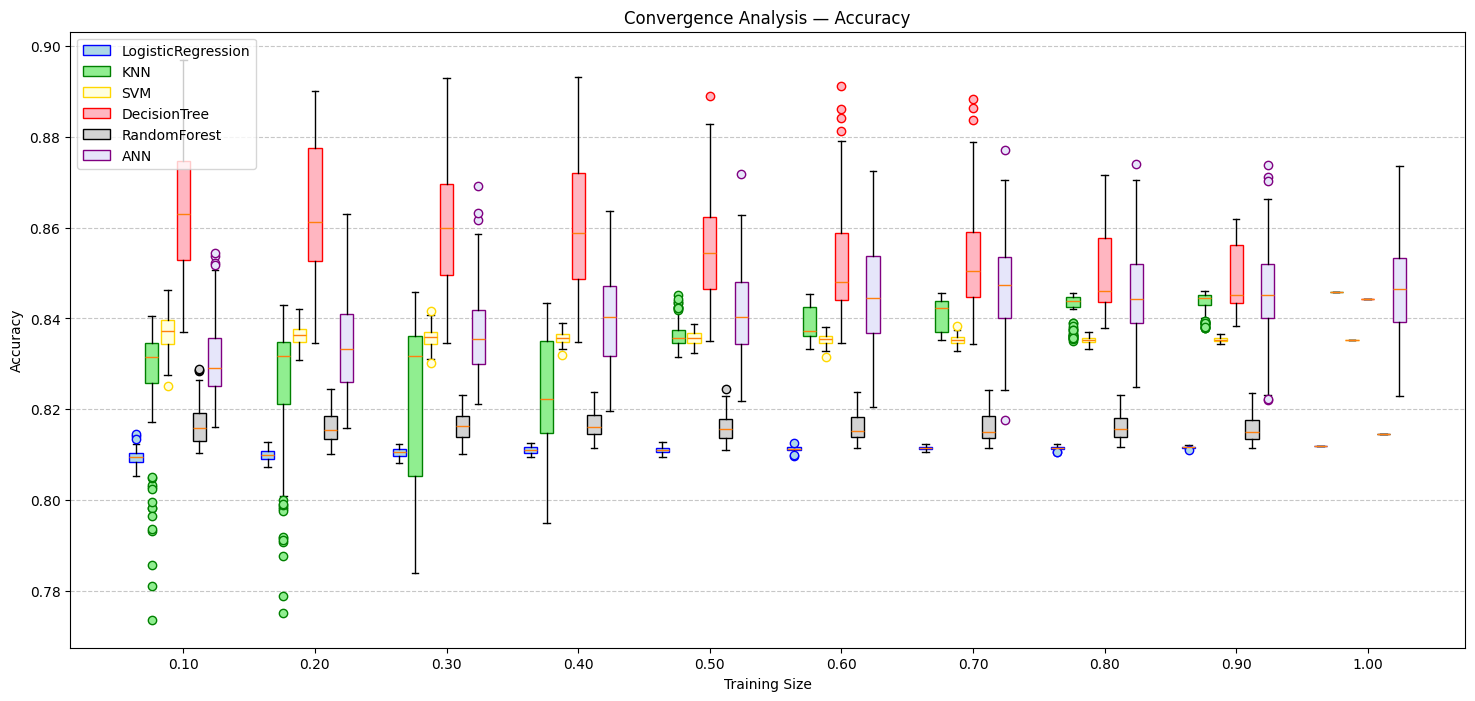

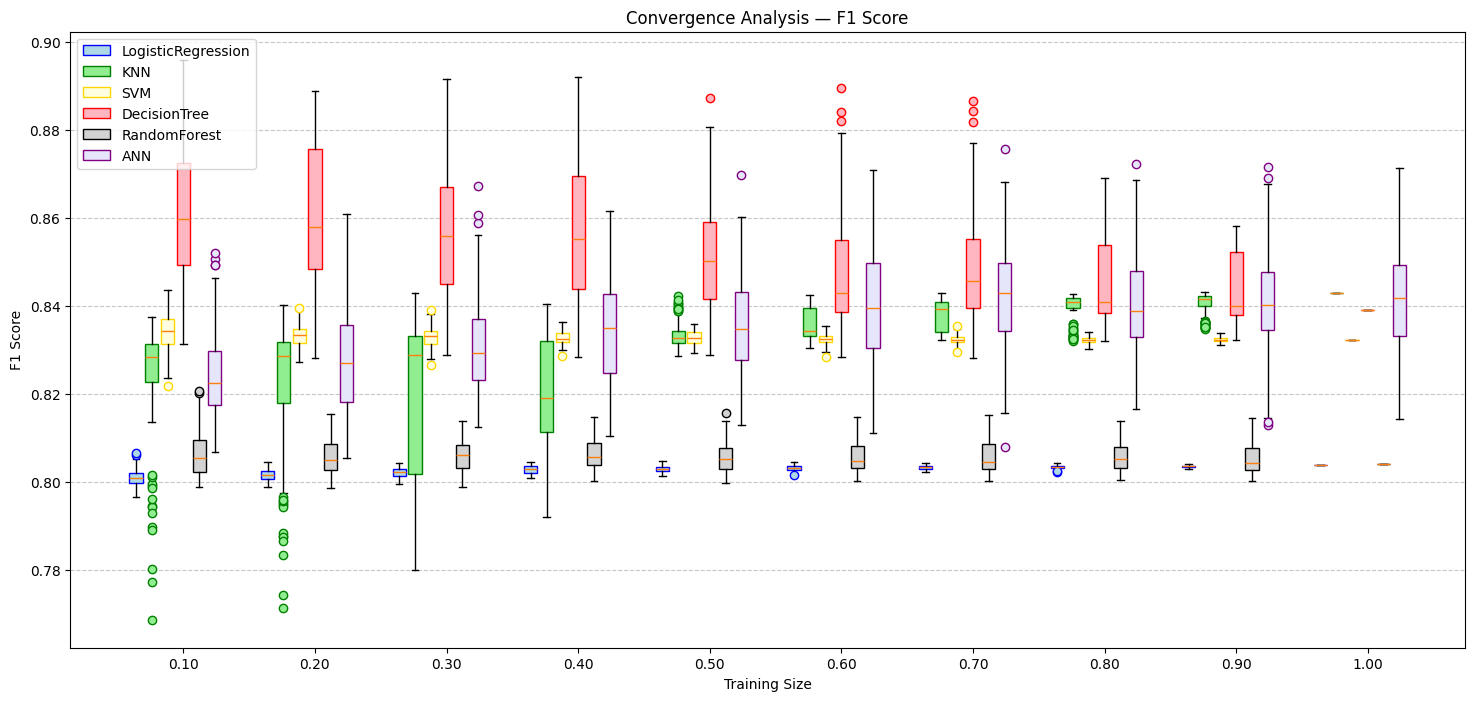

In [ ]:
colors = {
    "LogisticRegression": ("lightblue", "blue"),
    "KNN": ("lightgreen", "green"),
    "SVM": ("lightyellow", "gold"),
    "DecisionTree": ("lightpink", "red"),
    "RandomForest": ("lightgray", "black"),
    "ANN": ("lavender", "purple")
}

# === ACCURACY ===
plt.figure(figsize=(18, 8))
positions = np.arange(len(training_sizes))

for i, m in enumerate(models):
    data = [results_accuracy[m][f"{s:.2f}"] for s in training_sizes]

    offset = (i - len(models)/2) * 0.12
    plt.boxplot(
        data,
        positions=positions + offset,
        widths=0.1,
        patch_artist=True,
        boxprops=dict(facecolor=colors[m][0], color=colors[m][1]),
        flierprops=dict(markerfacecolor=colors[m][0], markeredgecolor=colors[m][1])
    )

legend_elements = [
    Rectangle((0,0),1,1,facecolor=colors[m][0],edgecolor=colors[m][1],label=m)
    for m in models
]

plt.legend(handles=legend_elements, loc="upper left")
plt.title("Convergence Analysis — Accuracy")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.xticks(positions, [f"{s:.2f}" for s in training_sizes])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig("SecondDatasetConvergenceAccuracy.png", dpi=300, bbox_inches='tight')
plt.show()

# === F1 SCORE ===
plt.figure(figsize=(18, 8))
positions = np.arange(len(training_sizes))

for i, m in enumerate(models):
    data = [results_f1[m][f"{s:.2f}"] for s in training_sizes]
    offset = (i - len(models)/2) * 0.12
    plt.boxplot(
        data,
        positions=positions + offset,
        widths=0.1,
        patch_artist=True,
        boxprops=dict(facecolor=colors[m][0], color=colors[m][1]),
        flierprops=dict(markerfacecolor=colors[m][0], markeredgecolor=colors[m][1])
    )

legend_elements = [
    Rectangle((0,0),1,1,facecolor=colors[m][0],edgecolor=colors[m][1],label=m)
    for m in models
]

plt.legend(handles=legend_elements, loc="upper left")
plt.title("Convergence Analysis — F1 Score")
plt.xlabel("Training Size")
plt.ylabel("F1 Score")
plt.xticks(positions, [f"{s:.2f}" for s in training_sizes])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig("SecondDatasetConvergenceF1.png", dpi=300, bbox_inches='tight')
plt.show()

The convergence analysis reveals that, unlike the first dataset where most models reached stable performance by 30–40% of the training data, models trained on UNSW-NB15 exhibit persistent variance across all training sizes, reflecting the greater complexity and feature dimensionality of the dataset. LogisticRegression and LinearSVC converge immediately but plateau at a lower performance ceiling, consistent with the linear separability limitations discussed earlier. KNN shows high variance at small training sizes due to the aggressive k=1 setting, stabilizing only partially as data increases. The DecisionTree displays persistently high variance throughout, suggesting sensitivity to the specific subsamples drawn at each iteration. RandomForest and ANN show the most consistent improvement with increasing training size, though neither reaches the sharp convergence observed in the first dataset, indicating that the problem complexity would benefit from even larger training sets.